## Experiment 3 — RGB to Grayscale: Channel Layout Comparison


**Objective:** This experiment implements an RGB-to-grayscale conversion using a custom CUDA kernel and compares the effect of **channel-last (HWC)** and **channel-first (CHW)** memory layouts on performance. The kernel reads the red, green, and blue values for each pixel, computes a grayscale intensity, and writes one output value per pixel. The goal is to verify correctness, benchmark execution time across different image sizes, and observe how memory layout changes the access pattern seen by neighboring CUDA threads. The experiment helps build intuition for how image tensor layout influences indexing, memory coalescing, and overall GPU efficiency.


## Implementation

In [1]:
!nvidia-smi

Mon Sep  7 02:11:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 5.0 MB/s eta 0:00:00a 0:00:01


In [3]:
# import libraries
import torch # for pytorch
from torch.utils.cpp_extension import load_inline # for loading cuda/c++ code
import matplotlib.pyplot as plt # for plotting
import time # for cpu timing

# versions
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")


PyTorch version: 2.11.0+cu128
CUDA available: True
cuDNN version: 91900


In this experiment, we will use different image sizes (H*W combinations and different scales) with 3 channels (stored in channel first and channel last formats), and a block size of 256 (max sweet spot before latency hiding stops working (too few blocks per SM)) to conduct the experiment.

We will try to verify the correctness, kernel execution time across these different image sizes.

In [4]:
image_sizes = [
    (256, 256),
    (512, 512),
    (1024, 1024),
    (2048, 2048)
]

BLOCK_SIZE = 256

In [5]:
def generate_random_image(width,height,channel_layout):
    input_image = torch.randint(0,256,(3,height,width),dtype=torch.uint8)
    if channel_layout=="HWC":
        # use permute to convert to HWC format
        input_image = input_image.permute(1,2,0).contiguous()
    else:
        # use permute to convert to CHW format
        input_image = input_image.permute(0,1,2).contiguous()
    return input_image


In [6]:
# test function
input_image = generate_random_image(256,256,"CHW")
print(input_image.shape)

torch.Size([3, 256, 256])


> Note: It doesnt really matter apart from your choice of comfort that we need to choose 2-dim block or 1-dim block; since the memory is loaded in a linear, contiguous fashion!

In [7]:
cpp_source = """
#include <torch/extension.h>

torch::Tensor kernel_hwc(torch::Tensor image, int block_size);
torch::Tensor kernel_chw(torch::Tensor image, int block_size);

"""
cuda_source = """

#include <torch/extension.h>
#include <cstdint>

//kernel for HWC

__global__ void kernel_hwc_cuda(const uint8_t* image, uint8_t* output, int width, int height){
    // Get the thread index
    int tid = blockIdx.x * blockDim.x + threadIdx.x;
    // Get the indexes for the input image to map to output pixel
    int r_index = tid*3;
    int g_index = tid*3 + 1;
    int b_index = tid*3 + 2;
    // Boundary check
    if (tid < height * width){
        float grayscale = 0.2989 * image[r_index] + 0.5870 * image[g_index] + 0.1140 * image[b_index];
        output[tid] = static_cast<uint8_t>(grayscale);
    }
}

//kernel for CHW

__global__ void kernel_chw_cuda(const uint8_t* image, uint8_t* output, int width, int height){
    // Get the thread index
    int tid = blockIdx.x * blockDim.x + threadIdx.x;
    // Get the indexes for the input image to map to output pixel
    int r_index=tid;
    int g_index=tid+width*height;
    int b_index=tid+2*width*height;
    // Boundary check
    if (tid < height * width){
        float grayscale = 0.2989 * image[r_index] + 0.5870 * image[g_index] + 0.1140 * image[b_index];
        output[tid] = static_cast<uint8_t>(grayscale);
    }
}

//kernel launcher for HWC

torch::Tensor kernel_hwc(torch::Tensor image, int block_size){
    TORCH_CHECK(block_size > 0 && block_size <= 1024,
                "block_size must be between 1 and 1024");
    // Implement Checks before launching the kernels
        //1. Check if image is on CUDA
    TORCH_CHECK(image.device().is_cuda(), "Image must be on CUDA");
        //2. Check if image is uint8
    TORCH_CHECK(
        image.scalar_type() == torch::kUInt8,
        "Image must be uint8"
    );
        //3. Check if image is 3 channels
    TORCH_CHECK(image.dim() == 3 && image.size(2) == 3, "Image must be 3 channels");
        //4. Check for contiguity
    TORCH_CHECK(image.is_contiguous(), "Image must be contiguous");
    // Get the height and width of the image
    int height = image.size(0);
    int width = image.size(1);
    // Create grayscale output tensor of shape [H, W]
    torch::Tensor output = torch::empty({height, width}, image.options());
    // Launch the kernel
    // Get the number of blocks and threads per block
    int num_blocks = (height * width + block_size - 1) / block_size;
    kernel_hwc_cuda<<<num_blocks, block_size>>>(image.data_ptr<uint8_t>(), output.data_ptr<uint8_t>(), width, height);
    // Return the result
    return output;
}

//kernel launcher for CHW

torch::Tensor kernel_chw(torch::Tensor image, int block_size){
    TORCH_CHECK(block_size > 0 && block_size <= 1024,
            "block_size must be between 1 and 1024");
    // Implement Checks before launching the kernels
        //1. Check if image is on CUDA
    TORCH_CHECK(image.device().is_cuda(), "Image must be on CUDA");
        //2. Check if image is uint8
    TORCH_CHECK(
        image.scalar_type() == torch::kUInt8,
        "Image must be uint8"
    );
        //3. Check if image is 3 channels
    TORCH_CHECK(image.dim() == 3 && image.size(0) == 3, "Image must be 3 channels");
        //4. Check for contiguity
    TORCH_CHECK(image.is_contiguous(), "Image must be contiguous");
    // Get the height and width of the image
    int height = image.size(1);
    int width = image.size(2);
    // Create grayscale output tensor of shape [H, W]
    torch::Tensor output = torch::empty({height, width}, image.options());
    // Launch the kernel
    // Get the number of blocks and threads per block
    int num_blocks = (height * width + block_size - 1) / block_size;
    kernel_chw_cuda<<<num_blocks, block_size>>>(image.data_ptr<uint8_t>(), output.data_ptr<uint8_t>(), width, height);
    // Return the result
    return output;

}


"""

In [8]:
rgb_grayscale_module = load_inline(
    name="rgb_grayscale_module",
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=["kernel_hwc", "kernel_chw"],
    extra_cflags=["-O2"],
    extra_cuda_cflags=["-O2"],
    verbose=True
)

In [9]:
def rgb_to_grayscale(image,channel_layout):

    def _check_and_run(image,channel_layout):
        if image.is_cuda:
            if image.dtype==torch.uint8:
                if channel_layout=="HWC":
                    return rgb_grayscale_module.kernel_hwc(image,BLOCK_SIZE)
                elif channel_layout=="CHW":
                    return rgb_grayscale_module.kernel_chw(image,BLOCK_SIZE)
                else:
                    raise ValueError("Invalid channel layout")
            else:
                raise ValueError("Image must be uint8")
        else:
            raise ValueError("Image must be on CUDA")

    # check what format was given
    if channel_layout=="HWC":
        # check if dim3 is 3
        if image.dim()==3 and image.size(2)==3:
            return _check_and_run(image,channel_layout)
        else:
            raise ValueError("Invalid image format")
    elif channel_layout=="CHW":
        # check if dim1 is 3
        if image.dim()==3 and image.size(0)==3:
            return _check_and_run(image,channel_layout)
        else:
            raise ValueError("Invalid image format")
    else:
        raise ValueError("Invalid channel layout")

In [17]:
def benchmark_rgb_grayscale(width, height, block_size=256, warmup=10, runs=1000):
    # Create one logical image in CHW format on CPU
    image_chw_cpu = torch.randint(
        0, 256,
        (3, height, width),
        dtype=torch.uint8
    )

    # Create HWC version of the same image
    image_hwc_cpu = image_chw_cpu.permute(1, 2, 0).contiguous()

    # Move both layouts to GPU
    image_chw = image_chw_cpu.to("cuda")
    image_hwc = image_hwc_cpu.to("cuda")

    # Warmup HWC
    for _ in range(warmup):
        out_hwc = rgb_grayscale_module.kernel_hwc(image_hwc, block_size)

    # Warmup CHW
    for _ in range(warmup):
        out_chw = rgb_grayscale_module.kernel_chw(image_chw, block_size)

    torch.cuda.synchronize()

    # CUDA events
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    # Benchmark HWC
    start.record()

    for _ in range(runs):
        out_hwc = rgb_grayscale_module.kernel_hwc(image_hwc, block_size)

    end.record()
    torch.cuda.synchronize()

    hwc_time_ms = start.elapsed_time(end) / runs

    # Benchmark CHW
    start.record()

    for _ in range(runs):
        out_chw = rgb_grayscale_module.kernel_chw(image_chw, block_size)

    end.record()
    torch.cuda.synchronize()

    chw_time_ms = start.elapsed_time(end) / runs

    # Correctness comparison
    correct = torch.equal(out_hwc, out_chw)

    return {
        "width": width,
        "height": height,
        "block_size": block_size,
        "hwc_time_ms": hwc_time_ms,
        "chw_time_ms": chw_time_ms,
        "outputs_equal": correct
    }

In [18]:
sizes = [
    (256, 256),
    (512, 512),
    (1024, 1024),
    (1920, 1080),
    (3840, 2160),
    (2160, 3840)
]

results = []

for width, height in sizes:
    results.append(
        benchmark_rgb_grayscale(width, height)
    )

    

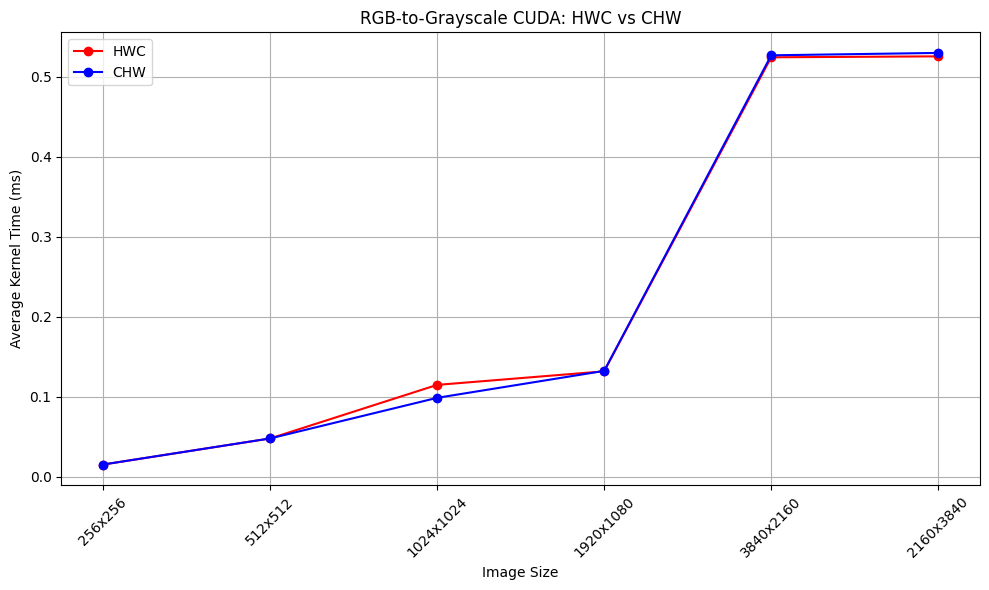

In [19]:

# Extract data
labels = [f"{r['width']}x{r['height']}" for r in results]
hwc_times = [r["hwc_time_ms"] for r in results]
chw_times = [r["chw_time_ms"] for r in results]

# Plot kernel latency
plt.figure(figsize=(10, 6))

plt.plot(labels, hwc_times, marker="o", label="HWC", color="red")
plt.plot(labels, chw_times, marker="o", label="CHW", color="blue")

plt.xlabel("Image Size")
plt.ylabel("Average Kernel Time (ms)")
plt.title("RGB-to-Grayscale CUDA: HWC vs CHW")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

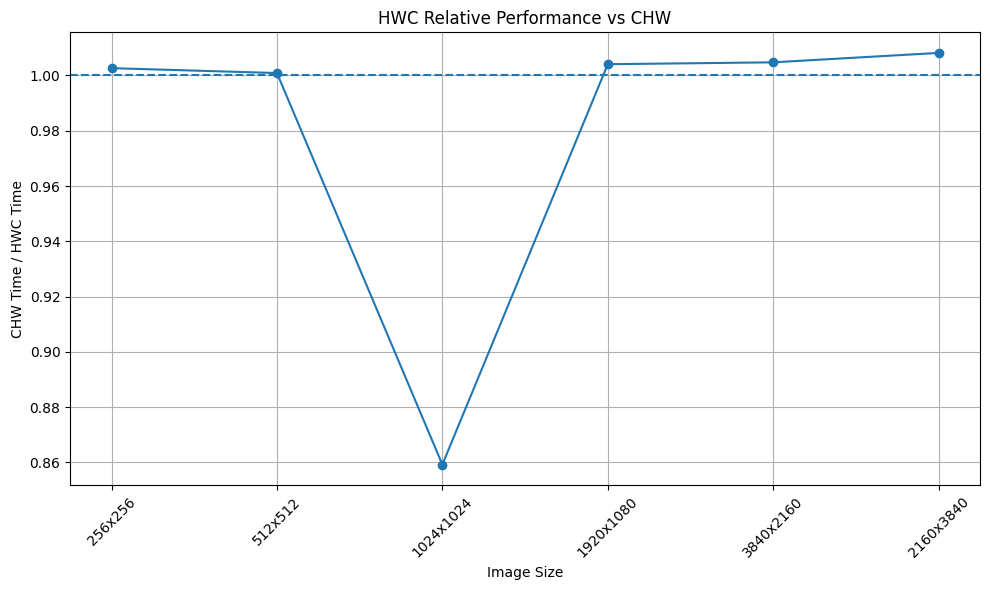

In [20]:
speedup = [
    chw / hwc
    for chw, hwc in zip(chw_times, hwc_times)
]

plt.figure(figsize=(10, 6))

plt.plot(labels, speedup, marker="o")

plt.axhline(1.0, linestyle="--")

plt.xlabel("Image Size")
plt.ylabel("CHW Time / HWC Time")
plt.title("HWC Relative Performance vs CHW")
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Observations

- HWC and CHW show nearly identical kernel performance across most tested image sizes.
- Increasing the number of benchmark runs to 1000 removed the large performance gap seen in earlier measurements, indicating that the previous result was likely caused by timing noise or transient GPU behavior.
- For most image sizes, the relative runtime differs by only about 1% or less.
- A larger difference appears around 1024×1024, but this should be treated as a possible outlier unless it is reproducible across repeated benchmark trials.
- Overall, for this simple RGB-to-grayscale kernel, both HWC and CHW layouts are handled efficiently, and memory layout has little practical impact on kernel latency under the tested conditions.
- The experiment also demonstrates the importance of warmup and repeated measurements when benchmarking short GPU kernels.